# ✅ Vérification de l'Environnement Container

**Vérification que nous sommes bien dans le container `mangetamain`**

In [5]:
# 🔍 Vérification complète de l'environnement
import os
import sys
import platform
import socket
from pathlib import Path

print("🔍 VÉRIFICATION DE L'ENVIRONNEMENT CONTAINER")
print("=" * 60)

# 1. Informations du système
print(f"🖥️  Système d'exploitation: {platform.system()} {platform.release()}")
print(f"🐍 Version Python: {sys.version}")
print(f"📁 Répertoire de travail actuel: {os.getcwd()}")
print(f"🏠 Répertoire home: {os.path.expanduser('~')}")

# 2. Variables d'environnement spécifiques au container
print(f"\n🐳 VARIABLES D'ENVIRONNEMENT CONTAINER:")
container_vars = ['HOSTNAME', 'CONTAINER_ID', 'PWD', 'USER', 'PATH']
for var in container_vars:
    value = os.environ.get(var, 'Non défini')
    print(f"   {var}: {value}")

# 3. Nom d'hôte (doit être différent de votre machine locale)
hostname = socket.gethostname()
print(f"\n🌐 Nom d'hôte: {hostname}")

# 4. Vérification de la structure du projet mangetamain
project_structure = [
    'pyproject.toml',
    'docker-compose.yml', 
    'Dockerfile',
    'main_nutrition_tagging.py',
    'main_time_prediction.py',
    'src',
    'data',
    'notebooks',
    'config'
]

print(f"\n📂 STRUCTURE DU PROJET MANGETAMAIN:")
current_dir = Path.cwd()
for item in project_structure:
    item_path = current_dir / item
    exists = "✅" if item_path.exists() else "❌"
    print(f"   {exists} {item}")

# 5. Vérification que nous sommes dans un container
print(f"\n🐳 INDICATEURS DE CONTAINER:")
indicators = [
    ("Fichier /.dockerenv", Path("/.dockerenv").exists()),
    ("Dans /workspace", "/workspace" in str(current_dir)),
    ("Variable CONTAINER_*", any(key.startswith('CONTAINER') for key in os.environ)),
]

for desc, check in indicators:
    status = "✅" if check else "❌"
    print(f"   {status} {desc}")

# 6. Vérification du kernel Python
print(f"\n🐍 KERNEL PYTHON:")
print(f"   Exécutable: {sys.executable}")
print(f"   Version: {sys.version_info}")
print(f"   Path modules: {sys.path[:3]}...")  # Premiers éléments du path

print(f"\n{'='*60}")
if "/workspace" in str(current_dir) and hostname != platform.node():
    print("🎉 CONFIRMÉ: Vous êtes bien dans le container mangetamain!")
else:
    print("⚠️  Vérifiez votre environnement - vous pourriez ne pas être dans le container")

🔍 VÉRIFICATION DE L'ENVIRONNEMENT CONTAINER
🖥️  Système d'exploitation: Linux 6.6.87.2-microsoft-standard-WSL2
🐍 Version Python: 3.11.14 (main, Oct  9 2025, 22:39:13) [GCC 14.2.0]
📁 Répertoire de travail actuel: /workspace
🏠 Répertoire home: /home/app

🐳 VARIABLES D'ENVIRONNEMENT CONTAINER:
   HOSTNAME: ae69daef841f
   CONTAINER_ID: Non défini
   PWD: /vscode/vscode-server/bin/linux-x64/7d842fb85a0275a4a8e4d7e040d2625abbf7f084
   USER: Non défini
   PATH: /usr/local/bin:/vscode/vscode-server/bin/linux-x64/7d842fb85a0275a4a8e4d7e040d2625abbf7f084/bin/remote-cli:/home/app/.local/bin:/home/app/.local/bin:/usr/local/bin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/vscode/vscode-server/bin/linux-x64/7d842fb85a0275a4a8e4d7e040d2625abbf7f084/bin/remote-cli:/home/app/.local/bin:/home/app/.local/bin:/usr/local/bin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin

🌐 Nom d'hôte: ae69daef841f

📂 STRUCTURE DU PROJET MANGETAMAIN:
   ✅ pyproject.toml
   ✅ docker-compose.y

In [6]:
# 🔧 Correction et vérification depuis le bon répertoire
import os
from pathlib import Path

# Aller au répertoire racine du projet
os.chdir('/workspace')
current_dir = Path.cwd()

print("🔧 VÉRIFICATION CORRIGÉE")
print("=" * 50)
print(f"📁 Nouveau répertoire de travail: {current_dir}")

# Re-vérification de la structure du projet
project_structure = [
    'pyproject.toml',
    'docker-compose.yml', 
    'Dockerfile',
    'main_nutrition_tagging.py',
    'main_time_prediction.py',
    'src',
    'data',
    'notebooks',
    'config'
]

print(f"\n📂 STRUCTURE DU PROJET MANGETAMAIN (corrigée):")
all_present = True
for item in project_structure:
    item_path = current_dir / item
    exists = item_path.exists()
    status = "✅" if exists else "❌"
    print(f"   {status} {item}")
    if not exists:
        all_present = False

print(f"\n🎯 RÉSULTAT FINAL:")
if all_present and "/workspace" in str(current_dir):
    print("🎉 CONFIRMÉ: Vous êtes bien dans le container mangetamain!")
    print("✅ Toutes les cellules s'exécuteront dans cet environnement")
else:
    print("⚠️  Il manque certains fichiers du projet")

🔧 VÉRIFICATION CORRIGÉE
📁 Nouveau répertoire de travail: /workspace

📂 STRUCTURE DU PROJET MANGETAMAIN (corrigée):
   ✅ pyproject.toml
   ✅ docker-compose.yml
   ✅ Dockerfile
   ✅ main_nutrition_tagging.py
   ✅ main_time_prediction.py
   ✅ src
   ✅ data
   ✅ notebooks
   ✅ config

🎯 RÉSULTAT FINAL:
🎉 CONFIRMÉ: Vous êtes bien dans le container mangetamain!
✅ Toutes les cellules s'exécuteront dans cet environnement


In [7]:
# 🛡️ Fonction de vérification rapide à utiliser n'importe quand
def verify_container_environment():
    """
    Fonction de vérification rapide pour s'assurer qu'on est dans le bon container
    Appelez cette fonction au début de vos cellules importantes si vous avez des doutes
    """
    import os
    import socket
    from pathlib import Path
    
    # Vérifications clés
    in_workspace = "/workspace" in os.getcwd()
    has_dockerenv = Path("/.dockerenv").exists()
    hostname = socket.gethostname()
    has_project_files = (Path("/workspace/pyproject.toml").exists() and 
                        Path("/workspace/src").exists())
    
    if in_workspace and has_dockerenv and has_project_files:
        print("✅ CONFIRMÉ: Dans le container mangetamain")
        return True
    else:
        print("❌ ATTENTION: Pas dans le bon environnement!")
        print(f"   Workspace: {in_workspace}")
        print(f"   Docker: {has_dockerenv}")
        print(f"   Fichiers projet: {has_project_files}")
        print(f"   Hostname: {hostname}")
        return False

# Test de la fonction
print("🧪 Test de la fonction de vérification:")
verify_container_environment()

print("\n💡 CONSEIL: Utilisez verify_container_environment() au début")
print("   de vos cellules importantes pour être sûr de votre environnement!")

🧪 Test de la fonction de vérification:
✅ CONFIRMÉ: Dans le container mangetamain

💡 CONSEIL: Utilisez verify_container_environment() au début
   de vos cellules importantes pour être sûr de votre environnement!


## 📋 Comment être sûr à 100% que vous êtes dans le bon container

### ✅ Indicateurs de confirmation

**Vous êtes dans le container `mangetamain` si :**

1. **🏠 Répertoire** : Vous êtes dans `/workspace`
2. **🐳 Docker** : Le fichier `/.dockerenv` existe  
3. **🏗️ Structure** : Tous les fichiers du projet sont présents
4. **🌐 Hostname** : Nom d'hôte aléatoire (ex: `ae69daef841f`)
5. **🐍 Python** : Version 3.11.14 installée dans `/usr/local/bin/python`

### 🛡️ Méthodes de vérification

**Option 1 - Fonction rapide :**
```python
verify_container_environment()  # Utilisez cette fonction définie ci-dessus
```

**Option 2 - Vérification manuelle :**
```python
import os
print(f"Répertoire: {os.getcwd()}")  # Doit être /workspace ou /workspace/notebooks
print(f"Docker: {os.path.exists('/.dockerenv')}")  # Doit être True
```

**Option 3 - Terminal :**
```bash
hostname  # Nom aléatoire du container
pwd       # /workspace
ls -la /  # Doit montrer .dockerenv
```

### ⚠️ Signes d'alerte

**Vous N'ÊTES PAS dans le container si :**
- Répertoire commence par `/Users/` (macOS) ou `/home/votre-nom/` (Linux local)
- Hostname = nom de votre machine locale
- Pas de fichier `/.dockerenv`
- Python dans `/usr/bin/python` au lieu de `/usr/local/bin/python`

### 🚀 Bonne pratique

**Ajoutez ceci au début de vos cellules importantes :**
```python
# Vérification rapide de l'environnement
if not verify_container_environment():
    raise EnvironmentError("Pas dans le bon container!")
```

# 🍽️ Exploration des Données Food.com

## Objectif du Notebook
Ce notebook permet d'explorer et d'analyser les données de recettes et d'interactions utilisateurs du dataset Food.com de Kaggle.

### Dataset Source
- **Lien Kaggle**: [Food.com Recipes and User Interactions](https://www.kaggle.com/datasets/shuyangli94/food-com-recipes-and-user-interactions)
- **Fichiers disponibles**:
  - `interactions_test.csv`, `interactions_train.csv`, `interactions_validation.csv`
  - `PP_recipes.csv`, `PP_users.csv`
  - `RAW_interactions.csv`, `RAW_recipes.csv`

### Plan d'analyse
1. **Configuration** - Structure du projet et imports
2. **Chargement** - Lecture de tous les fichiers CSV
3. **Vue d'ensemble** - Statistiques descriptives
4. **Relations** - Connexions entre les datasets
5. **Qualité** - Évaluation de la propreté des données
6. **Visualisation** - Graphiques exploratoires

## 1. 📁 Configuration et Structure du Projet

In [8]:
# Imports des bibliothèques essentielles
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
import os

# Configuration des graphiques
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
warnings.filterwarnings('ignore')

# Configuration du répertoire de travail
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = PROJECT_ROOT / 'data'
RAW_DATA_DIR = DATA_DIR / 'raw'
PROCESSED_DATA_DIR = DATA_DIR / 'processed'

print(f"📂 Répertoire du projet: {PROJECT_ROOT}")
print(f"📂 Répertoire des données brutes: {RAW_DATA_DIR}")
print(f"📂 Répertoire des données traitées: {PROCESSED_DATA_DIR}")

# Vérification de l'existence des répertoires
for directory in [DATA_DIR, RAW_DATA_DIR, PROCESSED_DATA_DIR]:
    directory.mkdir(exist_ok=True, parents=True)
    print(f"✅ {directory.name.upper()}: {'Existe' if directory.exists() else 'Créé'}")

📂 Répertoire du projet: /workspace
📂 Répertoire des données brutes: /workspace/data/raw
📂 Répertoire des données traitées: /workspace/data/processed
✅ DATA: Existe
✅ RAW: Existe
✅ PROCESSED: Existe


## 2. 📊 Chargement et Exploration des Fichiers CSV

**Instructions importantes:**
1. Placez tous vos fichiers CSV dans le dossier `data/raw/`
2. Les fichiers attendus sont:
   - `interactions_test.csv`, `interactions_train.csv`, `interactions_validation.csv`
   - `PP_recipes.csv`, `PP_users.csv`
   - `RAW_interactions.csv`, `RAW_recipes.csv`

In [9]:
# Définition des fichiers de données
FILES = {
    'interactions_train': 'interactions_train.csv',
    'interactions_test': 'interactions_test.csv', 
    'interactions_validation': 'interactions_validation.csv',
    'PP_recipes': 'PP_recipes.csv',
    'PP_users': 'PP_users.csv',
    'RAW_interactions': 'RAW_interactions.csv',
    'RAW_recipes': 'RAW_recipes.csv'
}

# Vérification de l'existence des fichiers
print("📋 Vérification des fichiers:")
existing_files = {}
for key, filename in FILES.items():
    file_path = RAW_DATA_DIR / filename
    if file_path.exists():
        print(f"✅ {filename}")
        existing_files[key] = file_path
    else:
        print(f"❌ {filename} - MANQUANT")

print(f"\n🔍 Fichiers trouvés: {len(existing_files)}/{len(FILES)}")

if not existing_files:
    print("\n⚠️  Aucun fichier trouvé!")
    print("📁 Placez vos fichiers CSV dans:", RAW_DATA_DIR)

📋 Vérification des fichiers:
✅ interactions_train.csv
✅ interactions_test.csv
✅ interactions_validation.csv
✅ PP_recipes.csv
✅ PP_users.csv
✅ RAW_interactions.csv
✅ RAW_recipes.csv

🔍 Fichiers trouvés: 7/7


In [10]:
# Fonction pour charger les données de manière sécurisée
def load_data_safe(file_path, max_rows=None):
    """Charge les données avec gestion d'erreurs"""
    try:
        if max_rows:
            df = pd.read_csv(file_path, nrows=max_rows)
            print(f"📊 Échantillon chargé ({max_rows} lignes)")
        else:
            df = pd.read_csv(file_path)
            print(f"📊 Dataset complet chargé")
        return df
    except Exception as e:
        print(f"❌ Erreur lors du chargement: {e}")
        return None

# Chargement des données disponibles
datasets = {}
for key, file_path in existing_files.items():
    print(f"\n📂 Chargement de {key}...")
    
    # Pour les gros fichiers, on charge d'abord un échantillon
    if 'RAW' in key:
        df = load_data_safe(file_path, max_rows=10000)  # Échantillon de 10k lignes
    else:
        df = load_data_safe(file_path)
    
    if df is not None:
        datasets[key] = df
        print(f"   📏 Forme: {df.shape}")
        print(f"   📋 Colonnes: {list(df.columns)}")

print(f"\n🎯 Datasets chargés avec succès: {len(datasets)}")


📂 Chargement de interactions_train...
📊 Dataset complet chargé
   📏 Forme: (698901, 6)
   📋 Colonnes: ['user_id', 'recipe_id', 'date', 'rating', 'u', 'i']

📂 Chargement de interactions_test...
📊 Dataset complet chargé
   📏 Forme: (12455, 6)
   📋 Colonnes: ['user_id', 'recipe_id', 'date', 'rating', 'u', 'i']

📂 Chargement de interactions_validation...
📊 Dataset complet chargé
   📏 Forme: (7023, 6)
   📋 Colonnes: ['user_id', 'recipe_id', 'date', 'rating', 'u', 'i']

📂 Chargement de PP_recipes...
📊 Dataset complet chargé
   📏 Forme: (698901, 6)
   📋 Colonnes: ['user_id', 'recipe_id', 'date', 'rating', 'u', 'i']

📂 Chargement de interactions_test...
📊 Dataset complet chargé
   📏 Forme: (12455, 6)
   📋 Colonnes: ['user_id', 'recipe_id', 'date', 'rating', 'u', 'i']

📂 Chargement de interactions_validation...
📊 Dataset complet chargé
   📏 Forme: (7023, 6)
   📋 Colonnes: ['user_id', 'recipe_id', 'date', 'rating', 'u', 'i']

📂 Chargement de PP_recipes...
📊 Dataset complet chargé
   📏 Forme: (1

## 3. 🔍 Vue d'ensemble et Statistiques Descriptives

In [11]:
# Analyse détaillée de chaque dataset
def analyze_dataset(name, df):
    """Analyse complète d'un dataset"""
    print(f"\n{'='*50}")
    print(f"📊 ANALYSE DE: {name.upper()}")
    print(f"{'='*50}")
    
    print(f"📏 Forme: {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
    
    print("\n📋 Types de données:")
    print(df.dtypes.value_counts())
    
    print("\n🔍 Valeurs manquantes:")
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    missing_info = pd.DataFrame({
        'Colonnes': df.columns,
        'Manquantes': missing,
        'Pourcentage': missing_pct.round(2)
    })
    print(missing_info[missing_info['Manquantes'] > 0].sort_values('Manquantes', ascending=False))
    
    print("\n📈 Statistiques numériques:")
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        print(df[numeric_cols].describe())
    
    print("\n🔤 Variables catégorielles:")
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns
    for col in categorical_cols[:3]:  # Limiter à 3 colonnes pour éviter trop de texte
        unique_count = df[col].nunique()
        print(f"   {col}: {unique_count:,} valeurs uniques")
        if unique_count <= 10:
            print(f"      Valeurs: {df[col].value_counts().head().to_dict()}")

# Analyse de tous les datasets disponibles
for name, df in datasets.items():
    analyze_dataset(name, df)


📊 ANALYSE DE: INTERACTIONS_TRAIN
📏 Forme: 698,901 lignes × 6 colonnes

📋 Types de données:
int64      4
object     1
float64    1
Name: count, dtype: int64

🔍 Valeurs manquantes:
Empty DataFrame
Columns: [Colonnes, Manquantes, Pourcentage]
Index: []

📈 Statistiques numériques:
Empty DataFrame
Columns: [Colonnes, Manquantes, Pourcentage]
Index: []

📈 Statistiques numériques:
            user_id      recipe_id         rating              u  \
count  6.989010e+05  698901.000000  698901.000000  698901.000000   
mean   1.247694e+07  156173.409849       4.574090    4249.330271   
std    1.525031e+08  126594.880211       0.959022    5522.602821   
min    1.533000e+03      38.000000       0.000000       0.000000   
25%    1.059880e+05   53169.000000       4.000000     455.000000   
50%    2.301020e+05  116484.000000       5.000000    1737.000000   
75%    4.801950e+05  234516.000000       5.000000    5919.000000   
max    2.002313e+09  537458.000000       5.000000   25075.000000   

         

## 4. 🔗 Relations entre les Datasets

In [12]:
# Exploration des relations entre datasets
def explore_relationships():
    """Analyse les clés de jointure potentielles"""
    
    print("🔗 ANALYSE DES RELATIONS ENTRE DATASETS")
    print("="*50)
    
    # Recherche des colonnes communes
    all_columns = {}
    for name, df in datasets.items():
        all_columns[name] = set(df.columns)
    
    print("\n📊 Colonnes communes:")
    for i, (name1, cols1) in enumerate(all_columns.items()):
        for name2, cols2 in list(all_columns.items())[i+1:]:
            common = cols1.intersection(cols2)
            if common:
                print(f"   {name1} ↔ {name2}: {common}")
    
    # Analyse des clés potentielles
    potential_keys = ['id', 'user_id', 'recipe_id', 'contributor_id']
    
    print("\n🔑 Analyse des clés potentielles:")
    for key in potential_keys:
        print(f"\n   Clé: {key}")
        for name, df in datasets.items():
            if key in df.columns:
                unique_count = df[key].nunique()
                total_count = len(df)
                uniqueness = unique_count / total_count
                print(f"      {name}: {unique_count:,}/{total_count:,} ({uniqueness:.1%} unique)")

# Exécution si des données sont disponibles
if datasets:
    explore_relationships()
else:
    print("⚠️ Aucun dataset disponible pour l'analyse des relations")

🔗 ANALYSE DES RELATIONS ENTRE DATASETS

📊 Colonnes communes:
   interactions_train ↔ interactions_test: {'u', 'rating', 'recipe_id', 'i', 'user_id', 'date'}
   interactions_train ↔ interactions_validation: {'u', 'rating', 'recipe_id', 'i', 'user_id', 'date'}
   interactions_train ↔ PP_recipes: {'i'}
   interactions_train ↔ PP_users: {'u'}
   interactions_train ↔ RAW_interactions: {'rating', 'user_id', 'recipe_id', 'date'}
   interactions_test ↔ interactions_validation: {'u', 'rating', 'recipe_id', 'i', 'user_id', 'date'}
   interactions_test ↔ PP_recipes: {'i'}
   interactions_test ↔ PP_users: {'u'}
   interactions_test ↔ RAW_interactions: {'rating', 'user_id', 'recipe_id', 'date'}
   interactions_validation ↔ PP_recipes: {'i'}
   interactions_validation ↔ PP_users: {'u'}
   interactions_validation ↔ RAW_interactions: {'rating', 'user_id', 'recipe_id', 'date'}
   PP_recipes ↔ PP_users: {'techniques'}
   PP_recipes ↔ RAW_recipes: {'id'}

🔑 Analyse des clés potentielles:

   Clé: id
    

## 5. 🧹 Évaluation de la Qualité des Données

In [13]:
# Évaluation complète de la qualité des données
def data_quality_assessment(name, df):
    """Évaluation complète de la qualité d'un dataset"""
    
    print(f"\n🔍 QUALITÉ DES DONNÉES: {name.upper()}")
    print("-" * 40)
    
    # 1. Doublons
    duplicates = df.duplicated().sum()
    print(f"🔄 Doublons: {duplicates:,} ({duplicates/len(df):.1%})")
    
    # 2. Valeurs manquantes
    missing_total = df.isnull().sum().sum()
    missing_pct = missing_total / (len(df) * len(df.columns))
    print(f"❓ Valeurs manquantes: {missing_total:,} ({missing_pct:.1%})")
    
    # 3. Colonnes avec beaucoup de valeurs uniques (potentiellement problématiques)
    high_cardinality_cols = []
    for col in df.columns:
        if df[col].nunique() > len(df) * 0.9:  # Plus de 90% de valeurs uniques
            high_cardinality_cols.append(col)
    
    if high_cardinality_cols:
        print(f"🎯 Colonnes haute cardinalité: {high_cardinality_cols}")
    
    # 4. Valeurs aberrantes pour les colonnes numériques
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        print(f"📊 Colonnes numériques analysées: {len(numeric_cols)}")
        
        for col in numeric_cols[:3]:  # Limiter à 3 colonnes
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            outliers = ((df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))).sum()
            if outliers > 0:
                print(f"   {col}: {outliers} valeurs aberrantes potentielles")

# Analyse de qualité pour tous les datasets
for name, df in datasets.items():
    data_quality_assessment(name, df)


🔍 QUALITÉ DES DONNÉES: INTERACTIONS_TRAIN
----------------------------------------
🔄 Doublons: 0 (0.0%)
❓ Valeurs manquantes: 0 (0.0%)
🔄 Doublons: 0 (0.0%)
❓ Valeurs manquantes: 0 (0.0%)
📊 Colonnes numériques analysées: 5
   user_id: 49659 valeurs aberrantes potentielles
   recipe_id: 1732 valeurs aberrantes potentielles
   rating: 27150 valeurs aberrantes potentielles

🔍 QUALITÉ DES DONNÉES: INTERACTIONS_TEST
----------------------------------------
🔄 Doublons: 0 (0.0%)
❓ Valeurs manquantes: 0 (0.0%)
🎯 Colonnes haute cardinalité: ['user_id', 'recipe_id', 'u', 'i']
📊 Colonnes numériques analysées: 5
   user_id: 598 valeurs aberrantes potentielles
   rating: 1247 valeurs aberrantes potentielles

🔍 QUALITÉ DES DONNÉES: INTERACTIONS_VALIDATION
----------------------------------------
🔄 Doublons: 0 (0.0%)
❓ Valeurs manquantes: 0 (0.0%)
🎯 Colonnes haute cardinalité: ['user_id', 'recipe_id', 'u', 'i']
📊 Colonnes numériques analysées: 5
   user_id: 361 valeurs aberrantes potentielles
   rati

## 6. 📈 Visualisations Exploratoires Initiales

📊 Génération des visualisations exploratoires...


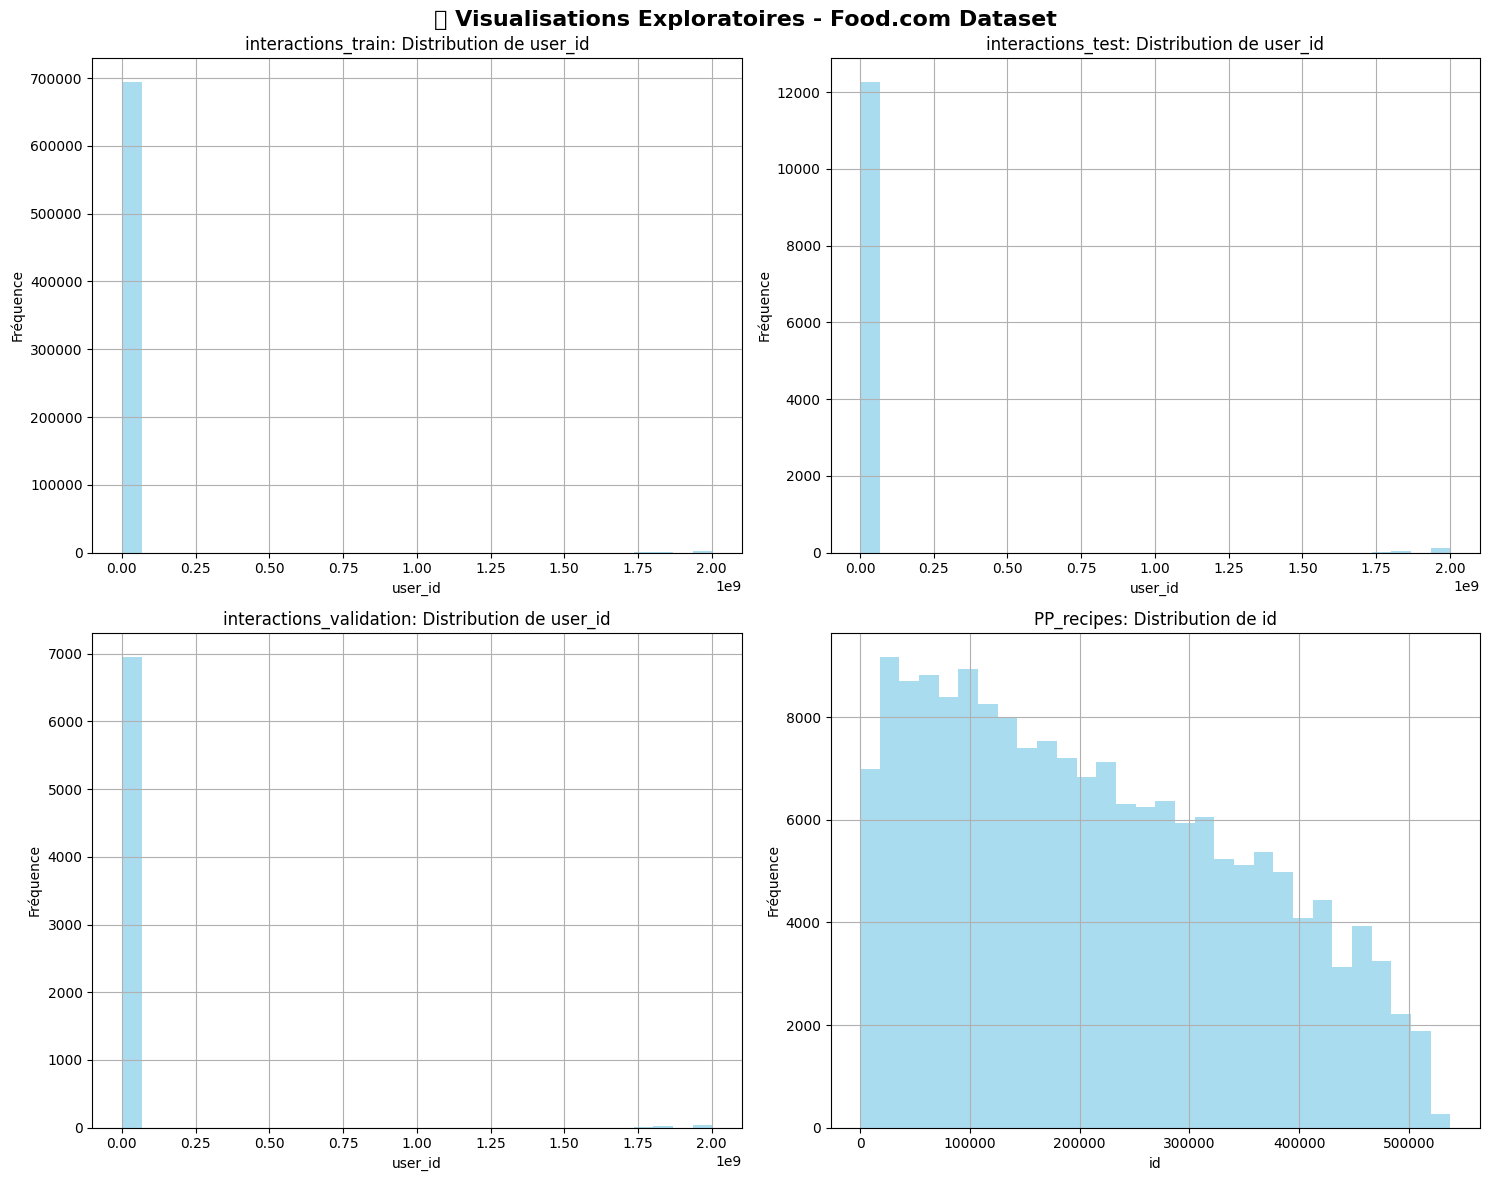


📈 Synthèse des datasets...


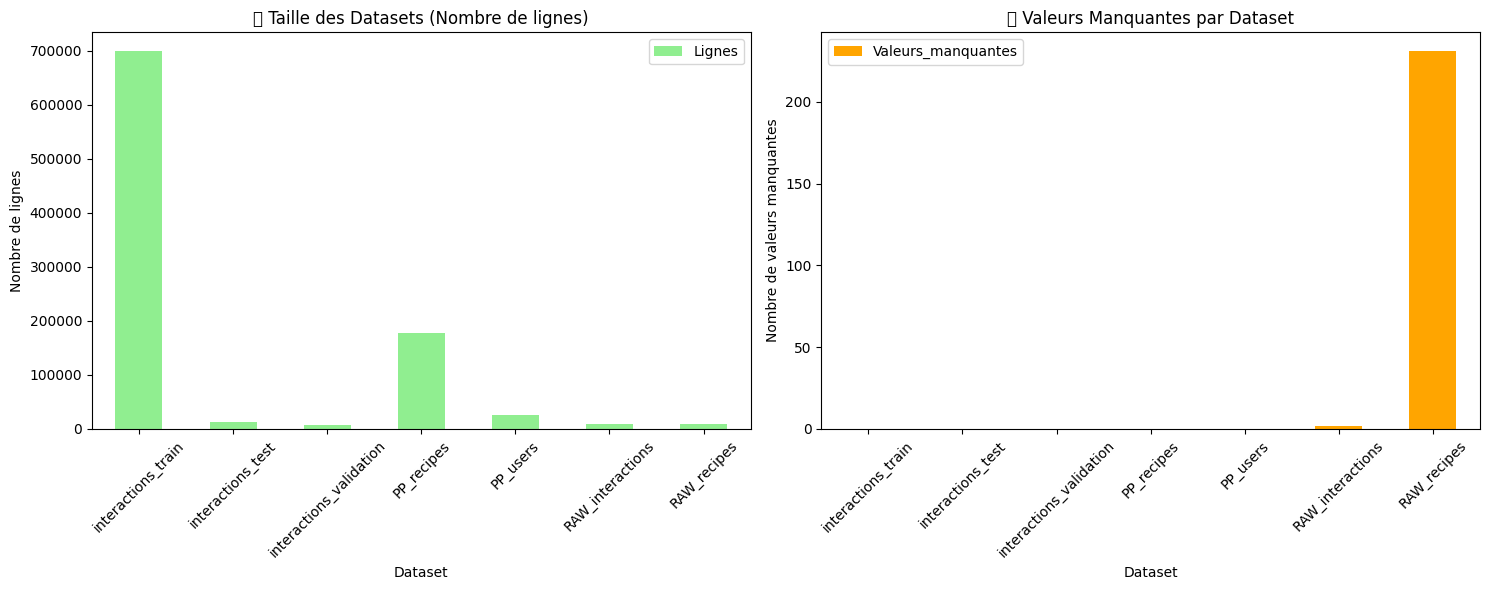


📋 Résumé numérique:
                   Dataset  Lignes  Colonnes  Valeurs_manquantes
0       interactions_train  698901         6                   0
1        interactions_test   12455         6                   0
2  interactions_validation    7023         6                   0
3               PP_recipes  178265         8                   0
4                 PP_users   25076         6                   0
5         RAW_interactions   10000         5                   2
6              RAW_recipes   10000        12                 231


In [14]:
# Créer des visualisations exploratoires
def create_initial_visualizations():
    """Génère des graphiques exploratoires selon les données disponibles"""
    
    if not datasets:
        print("⚠️ Aucune donnée disponible pour la visualisation")
        return
    
    # Configuration pour les graphiques
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('🍽️ Visualisations Exploratoires - Food.com Dataset', fontsize=16, fontweight='bold')
    
    plot_count = 0
    
    for name, df in datasets.items():
        if plot_count >= 4:  # Limiter à 4 graphiques
            break
            
        ax = axes[plot_count//2, plot_count%2]
        
        # Choisir le type de graphique selon les données disponibles
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        
        if len(numeric_cols) > 0:
            # Histogramme de la première colonne numérique
            col = numeric_cols[0]
            df[col].hist(bins=30, ax=ax, alpha=0.7, color='skyblue')
            ax.set_title(f'{name}: Distribution de {col}')
            ax.set_xlabel(col)
            ax.set_ylabel('Fréquence')
        else:
            # Graphique en barres pour les données catégorielles
            categorical_cols = df.select_dtypes(include=['object']).columns
            if len(categorical_cols) > 0:
                col = categorical_cols[0]
                top_values = df[col].value_counts().head(10)
                top_values.plot(kind='bar', ax=ax, color='lightcoral')
                ax.set_title(f'{name}: Top 10 {col}')
                ax.tick_params(axis='x', rotation=45)
            else:
                ax.text(0.5, 0.5, f'Pas de données\nvisualiser pour\n{name}', 
                       ha='center', va='center', transform=ax.transAxes)
                ax.set_title(f'{name}: Données non visualisables')
        
        plot_count += 1
    
    # Masquer les sous-graphiques non utilisés
    for i in range(plot_count, 4):
        axes[i//2, i%2].set_visible(False)
    
    plt.tight_layout()
    plt.show()

# Graphique de synthèse des datasets
def datasets_summary_plot():
    """Graphique de synthèse de tous les datasets"""
    
    if not datasets:
        print("⚠️ Aucune donnée disponible")
        return
    
    # Préparation des données pour le graphique de synthèse
    summary_data = []
    for name, df in datasets.items():
        summary_data.append({
            'Dataset': name,
            'Lignes': len(df),
            'Colonnes': len(df.columns),
            'Valeurs_manquantes': df.isnull().sum().sum()
        })
    
    summary_df = pd.DataFrame(summary_data)
    
    # Création du graphique
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Nombre de lignes par dataset
    summary_df.plot(x='Dataset', y='Lignes', kind='bar', ax=ax1, color='lightgreen')
    ax1.set_title('📊 Taille des Datasets (Nombre de lignes)')
    ax1.tick_params(axis='x', rotation=45)
    ax1.set_ylabel('Nombre de lignes')
    
    # Valeurs manquantes par dataset
    summary_df.plot(x='Dataset', y='Valeurs_manquantes', kind='bar', ax=ax2, color='orange')
    ax2.set_title('❓ Valeurs Manquantes par Dataset')
    ax2.tick_params(axis='x', rotation=45)
    ax2.set_ylabel('Nombre de valeurs manquantes')
    
    plt.tight_layout()
    plt.show()
    
    return summary_df

# Génération des visualisations
print("📊 Génération des visualisations exploratoires...")
create_initial_visualizations()

print("\n📈 Synthèse des datasets...")
if datasets:
    summary = datasets_summary_plot()
    print("\n📋 Résumé numérique:")
    print(summary)

## 🎯 Prochaines Étapes

### Actions Immédiates
1. **📁 Placez vos fichiers CSV** dans le dossier `data/raw/`
2. **▶️ Exécutez ce notebook** pour explorer vos données
3. **🔍 Analysez les résultats** pour comprendre votre dataset

### Analyse Approfondie Suggérée
- **Nettoyage des données** (valeurs manquantes, doublons)
- **Analyse des patterns d'interaction** utilisateur-recette
- **Exploration des caractéristiques nutritionnelles**
- **Modélisation prédictive** (temps de préparation, recommandations)

### Notebooks Suivants à Créer
- `02_data_cleaning.ipynb` - Nettoyage et préparation
- `03_eda_advanced.ipynb` - Analyse exploratoire avancée
- `04_feature_engineering.ipynb` - Ingénierie des caractéristiques
- `05_modeling.ipynb` - Développement des modèles

---

**💡 Conseil**: Commencez par placer vos fichiers CSV dans `data/raw/` puis exécutez toutes les cellules de ce notebook pour avoir une vue d'ensemble de vos données !